In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [22]:
# Load data
df = pd.read_csv('movies_cleaned.csv')
print("Original shape:", df.shape)

# Keep only rows where budget and revenue are non-zero
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
print("Cleaned shape:", df.shape)

Original shape: (4740, 20)
Cleaned shape: (3225, 20)


In [23]:
# Data preparation for scratch model (budget → revenue, simple linear regression)
X = df[['budget']].values  # 2D array, shape (n, 1)
y = df['revenue'].values    # 1D array, shape (n,)

# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Train/test split (80/20)
split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 2580
Test size: 645


In [24]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.loss_history = []

    def predict(self, X):
        return X @ self.w + self.b

    def compute_loss(self, y_pred, y_true):
        n = len(y_true)
        return (1 / n) * np.sum((y_pred - y_true) ** 2)

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0
        self.loss_history = []
        for epoch in range(self.epochs):
            y_pred = self.predict(X)
            dw = (2 / n) * X.T @ (y_pred - y)
            db = (2 / n) * np.sum(y_pred - y)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.loss_history.append(self.compute_loss(y_pred, y))
        return self

Scratch  — MSE: 0.07123042, w: 0.72342632, b: -0.02159421
Sklearn  — MSE: 0.07123043, w: 0.72342633, b: -0.02159423


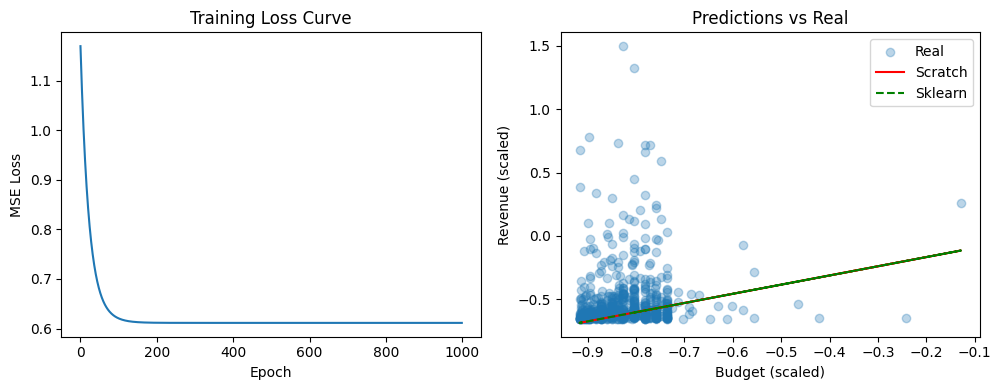

In [25]:
# Train from-scratch model (budget only, gradient descent demo)
model_scratch = LinearRegressionScratch(learning_rate=0.01, epochs=1000)
model_scratch.fit(X_train, y_train)

# Train sklearn model
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

# Predictions
y_pred_scratch = model_scratch.predict(X_test)
y_pred_sklearn = model_sklearn.predict(X_test)

# Compare metrics
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)

print(f"Scratch  — MSE: {mse_scratch:.8f}, w: {model_scratch.w[0]:.8f}, b: {model_scratch.b:.8f}")
print(f"Sklearn  — MSE: {mse_sklearn:.8f}, w: {model_sklearn.coef_[0]:.8f}, b: {model_sklearn.intercept_:.8f}")

# Plot loss curve + predictions
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(model_scratch.loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], y_test, alpha=0.3, label='Real')
plt.plot(X_test[:, 0], y_pred_scratch, color='red', label='Scratch')
plt.plot(X_test[:, 0], y_pred_sklearn, color='green', linestyle='--', label='Sklearn')
plt.xlabel('Budget (scaled)')
plt.ylabel('Revenue (scaled)')
plt.title('Predictions vs Real')
plt.legend()

plt.tight_layout()
plt.savefig('plot_loss_and_predictions.png', dpi=150)
plt.show()

In [26]:
# Feature set comparison — all 3 sets, scratch vs sklearn (holdout)
feature_sets = {
    'budget only': ['budget'],
    'budget + popularity': ['budget', 'popularity'],
    'budget + popularity + runtime + vote_count': ['budget', 'popularity', 'runtime', 'vote_count']
}

results = {}

for name, features in feature_sets.items():
    X = df[features].values
    y = df['revenue'].values

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    split = int(0.8 * len(X_scaled))
    X_train, X_test = X_scaled[:split], X_scaled[split:]
    y_train, y_test = y_scaled[:split], y_scaled[split:]

    # Scratch model
    model_s = LinearRegressionScratch(learning_rate=0.01, epochs=1000)
    model_s.fit(X_train, y_train)
    y_pred_s = model_s.predict(X_test)
    mse_s = mean_squared_error(y_test, y_pred_s)
    r2_s = r2_score(y_test, y_pred_s)

    # Sklearn model
    model_sk = LinearRegression()
    model_sk.fit(X_train, y_train)
    y_pred_sk = model_sk.predict(X_test)
    mse_sk = mean_squared_error(y_test, y_pred_sk)
    r2_sk = r2_score(y_test, y_pred_sk)

    results[name] = {'Scratch MSE': mse_s, 'Scratch R2': r2_s,
                     'Sklearn MSE': mse_sk, 'Sklearn R2': r2_sk}
    print(f"{name}:")
    print(f"  Scratch  — MSE={mse_s:.8f}, R2={r2_s:.8f}")
    print(f"  Sklearn  — MSE={mse_sk:.8f}, R2={r2_sk:.8f}")

budget only:
  Scratch  — MSE=0.07123042, R2=-0.18092108
  Sklearn  — MSE=0.07123043, R2=-0.18092121
budget + popularity:
  Scratch  — MSE=0.06678643, R2=-0.10724467
  Sklearn  — MSE=0.06678649, R2=-0.10724568
budget + popularity + runtime + vote_count:
  Scratch  — MSE=0.07985818, R2=-0.32395968
  Sklearn  — MSE=0.07986829, R2=-0.32412736


In [27]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, features in feature_sets.items():
    X = df[features].values
    y = df['revenue'].values

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    # Sklearn cross-validation
    scores_sk = cross_val_score(LinearRegression(), X_scaled, y_scaled, cv=kf, scoring='r2')

    # Scratch cross-validation (manual loop)
    scores_s = []
    for train_idx, test_idx in kf.split(X_scaled):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y_scaled[train_idx], y_scaled[test_idx]
        m = LinearRegressionScratch(learning_rate=0.01, epochs=1000)
        m.fit(X_tr, y_tr)
        scores_s.append(r2_score(y_te, m.predict(X_te)))
    scores_s = np.array(scores_s)

    print(f"{name}:")
    print(f"  Scratch  — Mean R2={scores_s.mean():.8f} (+/- {scores_s.std():.8f})")
    print(f"  Sklearn  — Mean R2={scores_sk.mean():.8f} (+/- {scores_sk.std():.8f})")

budget only:
  Scratch  — Mean R2=0.49589652 (+/- 0.04443737)
  Sklearn  — Mean R2=0.49589652 (+/- 0.04443737)
budget + popularity:
  Scratch  — Mean R2=0.58610239 (+/- 0.04464094)
  Sklearn  — Mean R2=0.58609542 (+/- 0.04464866)
budget + popularity + runtime + vote_count:
  Scratch  — Mean R2=0.68949593 (+/- 0.05191271)
  Sklearn  — Mean R2=0.68914167 (+/- 0.05154549)


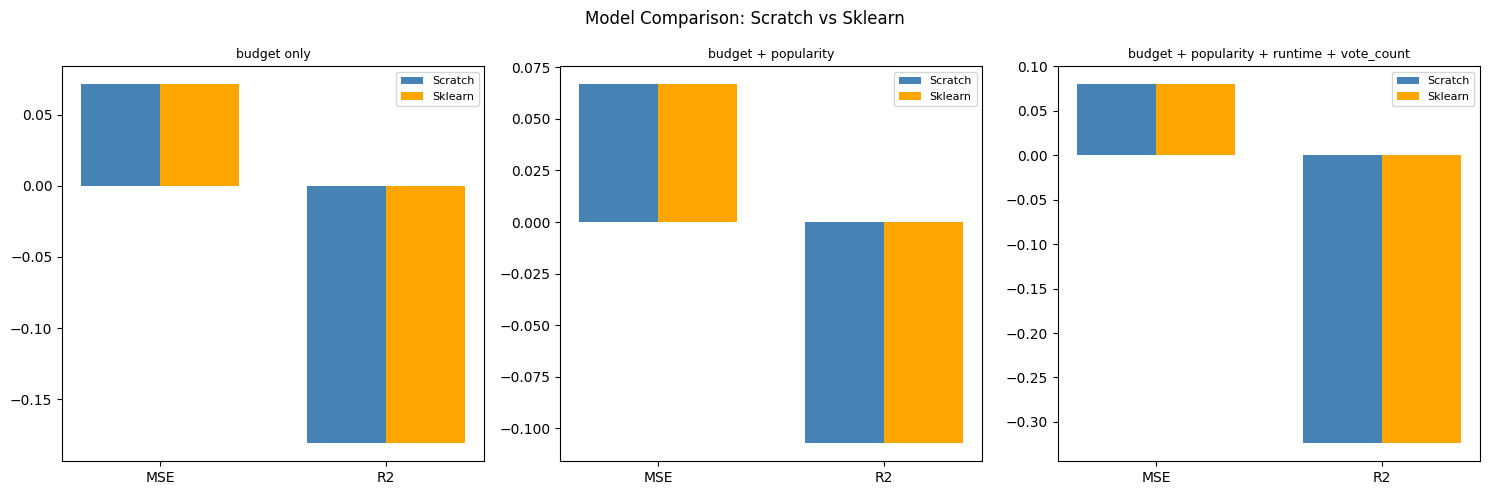

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(2)
width = 0.35
metric_labels = ['MSE', 'R2']

for ax, (name, metrics) in zip(axes, results.items()):
    ax.bar(x - width / 2, [metrics['Scratch MSE'], metrics['Scratch R2']],
           width, label='Scratch', color='steelblue')
    ax.bar(x + width / 2, [metrics['Sklearn MSE'], metrics['Sklearn R2']],
           width, label='Sklearn', color='orange')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison: Scratch vs Sklearn')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150)
plt.show()

In [29]:
from sklearn.preprocessing import PolynomialFeatures

X = df[['budget']].values
y = df['revenue'].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Scratch model
model_scratch_poly = LinearRegressionScratch(learning_rate=0.01, epochs=1000)
model_scratch_poly.fit(X_train_poly, y_train)
y_pred_scratch_poly = model_scratch_poly.predict(X_test_poly)
mse_s = mean_squared_error(y_test, y_pred_scratch_poly)
r2_s = r2_score(y_test, y_pred_scratch_poly)

# Sklearn model
model_sklearn_poly = LinearRegression()
model_sklearn_poly.fit(X_train_poly, y_train)
y_pred_sklearn_poly = model_sklearn_poly.predict(X_test_poly)
mse_sk = mean_squared_error(y_test, y_pred_sklearn_poly)
r2_sk = r2_score(y_test, y_pred_sklearn_poly)

print("Polynomial features (degree=2):")
print(f"  Scratch  — MSE={mse_s:.8f}, R2={r2_s:.8f}")
print(f"  Sklearn  — MSE={mse_sk:.8f}, R2={r2_sk:.8f}")

Polynomial features (degree=2):
  Scratch  — MSE=0.05987194, R2=0.00738984
  Sklearn  — MSE=0.05983587, R2=0.00798788
